In [244]:
import backtrader as bt
import backtrader.indicators as btind
import pandas as pd
import time

In [2]:
# import inspect
# file_path = inspect.getfile(bt.feeds)

In [31]:
pd.set_option('display.max_rows', None)
# pd.reset_option('all') # restore to default

In [4]:
import warnings
warnings.simplefilter(action='ignore',category=pd.errors.PerformanceWarning)

In [409]:
%run CommonUtil.ipynb

[0.004200000000000001, 0.0030952380952380953, 0.002285714285714286, 0.0016666666666666668, 0.0012000000000000001, 0.0009]


In [93]:
%run tradeUtil.ipynb

In [94]:
%run backTestUtil.ipynb

[0.004200000000000001, 0.0030952380952380953, 0.002285714285714286, 0.0016666666666666668, 0.0012000000000000001, 0.0009]


In [95]:
%run paraConfig.ipynb

[0.004200000000000001, 0.0030952380952380953, 0.002285714285714286, 0.0016666666666666668, 0.0012000000000000001, 0.0009]


In [96]:
# path = './data/IC2512.csv'
path = './data/IC2609.csv'

# 读数据

In [410]:
start = time.time()
base = prepare_back_test_data(path,para)
end = time.time()
print(f"耗时: {end - start:.2f} 秒")

<ipython-input-94-7b3608a4a236>:2: DtypeWarning: Columns (10,11,26,34,35,36,41,42,44,49,55,56,57,58,59,60,61,62,63,67,68,71,72,74,75,76,77,78,79,80,81,82,84,90,113,136,159,182,186,209,265) have mixed types. Specify dtype option on import or set low_memory=False.
  raw = pd.read_csv(path)


Shape of base: (13020, 463)
耗时: 1.60 秒


In [402]:
# base.loc['2026-09-08 13:25:00':'2026-09-08 13:40:00',['p_prev1_3']]
# base.loc['2026-09-08 10:32:00':'2026-09-08 13:40:00',['peak3_ext','p_prev1_3_ext']]

# Pattern

In [42]:
# 
base.loc['2026-08-31 14:35:00':'2026-09-01 09:31:00',['close','v3_strength','k_ups','ma_body','peak_zone_dt','peak_zone_td','peak_zone_prev1_td','mv_stage','slp1']]

,close,v3_strength,k_ups,ma_body,peak_zone_dt,peak_zone_td,peak_zone_prev1_td,mv_stage,slp1
time,,,,,,,,,
2026-08-31 14:35:00,7910.6,1.386726,2.4,4.46,1,6,0,2,1000.3933
2026-08-31 14:36:00,7904.0,0.948901,0.0,4.48,1,6,0,2,1000.0422
2026-08-31 14:37:00,7905.2,0.626803,0.8,3.52,1,6,0,2,1000.0735
2026-08-31 14:38:00,7895.0,0.860789,0.8,3.72,0,0,0,2,999.6838
2026-08-31 14:39:00,7902.8,0.695913,1.2,4.18,6,6,0,2,1000.0561
2026-08-31 14:40:00,7906.4,0.766769,1.8,4.34,1,6,0,2,1000.1703
2026-08-31 14:41:00,7908.8,1.134278,0.0,4.07,1,6,0,2,1000.2084
2026-08-31 14:42:00,7903.8,0.534623,1.4,4.24,1,6,0,2,999.9681
2026-08-31 14:43:00,7900.8,0.643468,1.2,4.27,6,6,0,1,999.8688


## peak3

### 反抽反弹peak3不突破

In [276]:
# 下跌后反抽peak3，然后下跌后形成新的peak3，此时的peak3在产生信号时不会有
# 实际中需要替换成peak_zone_td == 3, 此时没有突破peak3
peak3_prev1 =  (base.peak_zone_prev1_td==3)
# 没有上穿
# 实际中替换成 (base.abv_p_3==base.p_pos3) 
peak3_pattern2 = (base.peak3<=base.p_prev1_3) 
# 第二次反弹,下跌反弹形成peak3 peak3_pattern.loc['2026-09-02 11:19:00':'2026-09-02 11:22:00']
# 实际中替换成 (base.p_prev1_3/base/peak3>=1.003)
peak3_pattern3 = (base.p_prev2_3/base.p_prev1_3>=1.003)
peak3_pattern = (base.peak_zone_td == 3)

peak3_pattern = peak3_pattern1 #&peak3_pattern2
ma_pattern = (base.ma_category_l==1) & (base.ma_category_m<4)
k_pattern1 = (base.close.shift(1)>=base.close.shift(2)) & (base.bsp_label.shift(1) >=2) \
& (base.kbody.shift(2)>base.ma_body*0.7) & (-base.kbody > base.ma_body*0.7)
# 还在peak3 zone
sig1 =peak3_pattern& ma_pattern # & k_pattern1
# 前一个还在peak3 zone，下跌后不在
sig2 = (peak3_pattern.shift(1)==True) & (peak3_pattern==False)
# test = (base.p_prev1_3/base.peak3>1.003) & (/base.peak_zone == 3) & (base.zd_strength <-2) & (base.mv_stage == 1)

In [277]:
# base.loc['2026-09-02 10:41:00':'2026-09-02 10:52:00',['abv_p_prev1_3','abv_p_3','p_pos3','ma_lows']]
# base.loc['2026-09-02 13:29:00':'2026-09-02 13:38:00',['abv_p_prev1_3','blw_p_3','abv_p_3','p_pos3','ma_lows']]
# peak3_pattern.loc['2026-09-02 10:41:00':'2026-09-02 10:52:00']
# 失败case
# peak3_pattern.loc['2026-09-02 11:19:00':'2026-09-02 11:22:00']

# base.loc[(peak3_pattern == True),['up_pct_3','dw_pct_3','peak3','close','p_prev1_3']]
base.loc[(peak3_pattern == True),['up_pct_3','dw_pct_3','p_prev1_3','cnt_abv_v_prev1_3']].drop_duplicates(subset=['dw_pct_3'],keep='first')

,up_pct_3,dw_pct_3,p_prev1_3,cnt_abv_v_prev1_3
time,,,,
2026-06-30 09:41:00,25.992915,NaN,8535.0,0
2026-07-01 09:46:00,NaN,-5.633867,8827.2,6
2026-07-01 10:21:00,NaN,-5.678733,8839.4,6
2026-07-01 11:13:00,NaN,-8.500564,8840.0,30
2026-07-02 11:01:00,NaN,-6.694213,8606.0,75
2026-07-02 11:16:00,NaN,-16.792379,8664.2,8
2026-07-06 09:55:00,NaN,-23.039433,8578.6,11
2026-07-06 13:59:00,NaN,-12.684096,8504.6,26
2026-07-08 11:30:00,NaN,-15.816887,8358.0,30


In [ ]:
base.loc[(peak3_pattern == True),['up_pct_3','dw_pct_3','p_prev1_3','cnt_abv_v_prev1_3']]

In [280]:
base.loc['2026-09-07 09:53:00':'2026-09-07 10:03:00',['close','peak_zone_td','cnt_abv_p3']]

,close,peak_zone_td
time,,
2026-09-07 09:53:00,7706.4,3
2026-09-07 09:54:00,7720.2,0
2026-09-07 09:55:00,7720.6,2
2026-09-07 09:56:00,7711.8,2
2026-09-07 09:57:00,7708.0,3
2026-09-07 09:58:00,7707.6,3
2026-09-07 09:59:00,7705.0,3
2026-09-07 10:00:00,7693.6,3
2026-09-07 10:01:00,7692.4,3


In [180]:
base.loc[sig1==True,['abv_p_prev1_3','up_pct_3','dw_pct_3','peak_bk3','valley_bk3']]

,up_pct_3,dw_pct_3,peak_bk3,valley_bk3
time,,,,
2026-07-02 11:01:00,NaN,-6.694213,8670.6,8606.2
2026-07-02 11:02:00,NaN,-6.694213,8670.6,8606.2
2026-07-02 11:03:00,NaN,-6.694213,8670.6,8606.2
2026-07-02 11:04:00,NaN,-6.694213,8670.6,8606.2
2026-07-02 11:05:00,NaN,-6.694213,8670.6,8606.2
2026-07-02 11:06:00,NaN,-6.694213,8670.6,8606.2
2026-07-02 11:07:00,NaN,-6.694213,8670.6,8606.2
2026-07-02 11:08:00,7.482977,NaN,8670.6,8606.2
2026-07-02 11:09:00,7.482977,NaN,8670.6,8525.0


In [145]:
# sig2.sum()
sig2[sig2==True]

time
2026-07-01 09:49:00    True
2026-07-01 10:04:00    True
2026-07-01 10:22:00    True
2026-07-01 10:26:00    True
2026-07-01 10:58:00    True
2026-07-01 11:02:00    True
2026-07-06 09:57:00    True
2026-07-09 13:31:00    True
2026-07-09 13:38:00    True
2026-07-14 10:00:00    True
2026-07-14 10:19:00    True
2026-07-22 14:34:00    True
2026-07-23 09:36:00    True
2026-07-23 09:39:00    True
2026-07-23 09:53:00    True
2026-07-23 11:19:00    True
2026-07-23 13:05:00    True
2026-07-23 13:09:00    True
2026-07-27 09:36:00    True
2026-07-27 09:48:00    True
2026-07-27 09:53:00    True
2026-07-28 13:45:00    True
2026-07-29 09:31:00    True
2026-07-29 09:35:00    True
2026-08-11 09:31:00    True
2026-08-11 10:16:00    True
2026-08-11 10:26:00    True
2026-08-11 10:28:00    True
2026-09-01 14:47:00    True
2026-09-02 10:47:00    True
2026-09-02 10:52:00    True
2026-09-02 11:26:00    True
2026-09-02 11:30:00    True
2026-09-02 13:35:00    True
2026-09-02 13:39:00    True
2026-09-02 13:5

In [142]:
test[test==True]

time
2026-07-27 09:44:00    True
2026-09-01 14:46:00    True
2026-09-02 10:46:00    True
2026-09-02 11:21:00    True
dtype: bool

In [139]:
# k_pattern1.loc['2026-09-02 10:41:00':'2026-09-02 10:52:00',['ma_body','k_lows','ma_lows']]
# k_pattern1.loc['2026-09-02 10:41:00':'2026-09-02 10:52:00']

time
2026-09-02 10:41:00    False
2026-09-02 10:42:00    False
2026-09-02 10:43:00    False
2026-09-02 10:44:00    False
2026-09-02 10:45:00    False
2026-09-02 10:46:00     True
2026-09-02 10:47:00    False
2026-09-02 10:48:00    False
2026-09-02 10:49:00    False
2026-09-02 10:50:00    False
2026-09-02 10:51:00    False
2026-09-02 10:52:00    False
dtype: bool

In [150]:
base.loc['2026-09-02 10:41:00':'2026-09-02 10:52:00',['close','peak_zone_prev1_td','p_prev1_3','p_prev2_3','peak_zone_td','peak_zone_prev1_td','peak4','p_prev1_4','peak_zone_dt','peak5','peak_zone_td','peak_zone_prev1_td','mv_stage','slp1']]

,close,peak_zone_prev1_td,p_prev1_3,p_prev2_3,peak_zone_td,peak_zone_prev1_td,peak4,p_prev1_4,peak_zone_dt,peak5,peak_zone_td,peak_zone_prev1_td,mv_stage,slp1
time,,,,,,,,,,,,,,
2026-09-02 10:41:00,7643.6,0,7823.6,7827.4,2,0,7845.0,7910.6,2,7910.6,2,0,1,1000.6454
2026-09-02 10:42:00,7644.4,0,7823.6,7827.4,0,0,7845.0,7910.6,0,7910.6,0,0,1,1000.4906
2026-09-02 10:43:00,7650.0,2,7823.6,7827.4,3,2,7845.0,7910.6,3,7910.6,3,2,1,1000.5598
2026-09-02 10:44:00,7654.8,2,7823.6,7827.4,3,2,7845.0,7910.6,3,7910.6,3,2,1,1000.5792
2026-09-02 10:45:00,7656.0,3,7658.4,7823.6,3,3,7845.0,7910.6,1,7910.6,3,3,1,1000.4583
2026-09-02 10:46:00,7651.6,3,7658.4,7823.6,3,3,7845.0,7910.6,1,7910.6,3,3,2,1000.1628
2026-09-02 10:47:00,7644.0,2,7658.4,7823.6,3,2,7845.0,7910.6,3,7910.6,3,2,2,999.8324
2026-09-02 10:48:00,7648.2,3,7658.4,7823.6,3,3,7845.0,7910.6,2,7910.6,3,3,1,1000.0372
2026-09-02 10:49:00,7650.6,3,7658.4,7823.6,3,3,7845.0,7910.6,1,7910.6,3,3,1,1000.1162


### 反抽peak3_prev1

In [367]:

# def 
# 实时替换为peak3_prev1, 回测是反抽peak3_prev2
peak_zone = (base.peak_zone_prev2_dt==3) & (base.p_prev1_3/base.p_prev2_3>=conf['zig']['zig3']) 
# 判断属于哪种类型

# 双重压力，可能也是突破
# 反弹:大级别的下跌，小级别反弹
peak_pattern1 = (base.p_pos3<base.p_pos4) 
# 震荡: 级别4跌穿vally3，反弹到p_prev1_3
peak_pattern2 = (base.peak_ext3>base.p_pos4) | (base.p_pos3>base.p_pos4) | (base.p_pos3>base.p_pos5)

peak3_thresh = peak_zone & peak_pattern2

In [368]:
# base.loc['2026-09-07 10:36:00':'2026-09-07 10:52:00',['p_prev1_4','p_prev2_4']]
# peak3_prev1.loc['2026-09-07 10:36:00':'2026-09-07 10:52:00']
base.loc[peak3_thresh,['p_pos3','p_pos4','up_pct_3','dw_pct_3','p_prev1_3','p_prev2_3','cnt_v1_in_v3','cnt_v2_in_v3']].drop_duplicates(subset=['dw_pct_3'],keep='first')
#          ['peak_zone_prev2_td','peak_zone_prev2_dt','peak_zone_prev1_td']]

,p_pos3,p_pos4,up_pct_3,dw_pct_3,p_prev1_3,p_prev2_3,cnt_v1_in_v3,cnt_v2_in_v3
time,,,,,,,,


## peak4

### 反抽peak4

In [229]:
# 反抽peak4，不突破， 形成peak4_prev1 
# 实际中需要替换成peak_zone_td , 此时没有突破peak3
peak4_pattern1 =  (base.peak_zone_prev1_td==3)
# 没有上穿
# 实际中替换成 (base.abv_p_3==base.p_pos3) 
peak4_pattern2 = (base.peak3<=base.p_prev1_3) 
peak4_pattern = peak4_pattern1&peak4_pattern2

In [230]:
base.loc[(peak4_pattern == True),['up_pct_4','dw_pct_4','peak4','close','p_prev1_4']].drop_duplicates(subset=['dw_pct_4'],keep='first')

,up_pct_4,dw_pct_4,peak4,close,p_prev1_4
time,,,,,
2026-07-06 09:55:00,NaN,-30.679531,8644.2,8576.6,8534.0
2026-07-08 11:25:00,20.232059,NaN,8372.4,8361.2,8514.6
2026-07-13 13:41:00,NaN,-14.888643,8127.0,8127.0,8615.4
2026-07-16 10:10:00,NaN,-45.399200,8048.6,8048.6,8084.8
2026-07-17 10:05:00,NaN,-23.331273,7766.4,7758.8,8048.6
2026-07-27 09:33:00,NaN,-21.341222,7572.2,7469.4,7584.0
2026-07-28 13:43:00,NaN,-48.874044,7664.6,7352.4,7605.4
2026-09-01 14:45:00,NaN,-31.943913,7845.0,7823.6,7910.6


## 反抽peak5

In [59]:
# 反抽peak5，没有形成新的peak5
z_pattern = (base.peak_zone_td==5) & (base.slp1.shift(1)>=1000) 
v_pattern = (base.mv_stage>=2)
k_pattern = (-base.kbody > base.ma_body )
test = z_pattern & v_pattern & k_pattern
base.loc['2026-08-25 10:18:00':'2026-08-25 10:26:00',['close','kbody','ma_body','peak4','p_prev1_4','peak_zone_dt','peak5','peak_zone_td','peak_zone_prev1_td','mv_stage','slp1']]
# base.loc['2026-08-26 09:35:00':'2026-08-26 10:00:00',['close','peak4','peak5','peak_zone_td','peak_zone_dt']]

,close,kbody,ma_body,peak4,p_prev1_4,peak_zone_dt,peak5,peak_zone_td,peak_zone_prev1_td,mv_stage,slp1
time,,,,,,,,,,,
2026-08-25 10:18:00,7622.8,13.6,7.69,7629.6,7789.6,3,7629.6,5,0,1,1000.8959
2026-08-25 10:19:00,7624.8,1.0,7.29,7624.8,7629.6,1,7629.6,5,4,3,1000.7145
2026-08-25 10:20:00,7614.2,-12.2,7.46,7624.8,7629.6,3,7629.6,5,1,3,1000.1121
2026-08-25 10:21:00,7615.2,0.8,7.19,7624.8,7629.6,3,7629.6,5,4,2,1000.1176
2026-08-25 10:22:00,7610.2,-6.0,7.40,7624.8,7629.6,4,7629.6,5,1,1,999.8963
2026-08-25 10:23:00,7604.2,-4.8,6.63,7624.8,7629.6,0,7629.6,0,1,1,999.7007
2026-08-25 10:24:00,7611.6,6.8,5.80,7624.8,7629.6,4,7629.6,5,1,1,1000.0640
2026-08-25 10:25:00,7613.0,1.6,5.64,7624.8,7629.6,3,7629.6,5,1,1,1000.0983
2026-08-25 10:26:00,7597.0,-15.6,6.10,7624.8,7629.6,0,7629.6,0,0,1,999.4696


## 反抽peak6

In [56]:
# 反抽peak6，没有超过peak6，没有形成新peak6
z6_pattern= ((base.peak_zone_td ==6) | (base.peak_zone_td.shift(1)==6)) 
z1_pattern = ((base.peak_zone_dt == 1) | (base.peak_zone_prev1_dt==1))
v_pattern = (base.mv_stage == 1)
bsp_pattern = (base.bsp_label>=2)
# 2阴启动，2阳反弹减速
sig1 = (-base.kbody.shift(3) >base.ma_body.shift(4) ) & (-base.kbody.shift(2) >base.ma_body.shift(3) )\
    & (base.kbody.shift(1) >base.ma_body.shift(2) ) & (base.kbody > 0) & (base.kbody <base.ma_body.shift(1) )\
    & (base.close<base.open.shift(3))
sig2 = (base.v3_strength >= 4) & (base.k_ups > base.ma_body*2)
# & (base.kbody>base.ma_body)
test = z6_pattern  & sig2
# base.loc['2026-08-04 13:45:00':'2026-08-04 14:05:00',['close','peak6','peak_zone_td','peak_zone_dt','mv_stage','bsp_label']]

# base.loc['2026-08-31 14:35:00':'2026-09-01 09:31:00',['close','kbody','p_pos6','peak6','peak_zone_dt','peak_zone_td','peak_zone_prev1_td','mv_stage','slp1']]
# base.loc['2026-07-30 09:31:00':'2026-07-30 09:50:00',['close','kbody','p_pos6','peak6','peak_zone_dt','peak_zone_td','peak_zone_prev1_td','mv_stage','slp1']]
base.loc['2026-08-31 14:41:00':'2026-09-01 09:35:00',['close','kbody','p_pos6','peak6','peak_zone_prev1_td','peak_zone_td','mv_stage','slp1']]

,close,kbody,p_pos6,peak6,peak_zone_prev1_td,peak_zone_td,mv_stage,slp1
time,,,,,,,,
2026-08-31 14:41:00,7908.8,2.8,453,7928.8,5,6,2,1000.2084
2026-08-31 14:42:00,7903.8,-4.6,454,7928.8,0,6,2,999.9681
2026-08-31 14:43:00,7900.8,-2.0,455,7928.8,0,6,1,999.8688
2026-08-31 14:44:00,7898.6,-2.2,456,7928.8,0,6,2,999.8267
2026-08-31 14:45:00,7899.4,1.2,457,7928.8,0,6,1,999.9051
2026-08-31 14:46:00,7902.4,2.6,458,7928.8,0,6,1,1000.0407
2026-08-31 14:47:00,7907.2,3.6,459,7928.8,5,6,2,1000.2026
2026-08-31 14:48:00,7903.4,-3.2,460,7928.8,0,6,2,1000.0073
2026-08-31 14:49:00,7908.4,5.4,461,7928.8,5,6,1,1000.1860


In [50]:
test[test==True]

time
2026-06-30 09:31:00    True
2026-06-30 09:32:00    True
2026-07-15 09:31:00    True
2026-07-28 09:31:00    True
2026-07-31 09:31:00    True
2026-07-31 09:33:00    True
2026-09-01 09:31:00    True
dtype: bool

## 反弹

In [118]:
base.loc['2026-09-04 13:00:00':'2026-09-04 13:25:00',['close','z_pct_curr2','z_pct_curr3','p_pos1','p_pos2','p_pos3','v_pos2','v_pos3','v_pos4','v_pos5','v_pos6','peak_zone_td','peak_zone_dt','mv_stage','bsp_label','slp1']]

,close,z_pct_curr2,z_pct_curr3,p_pos1,p_pos2,p_pos3,v_pos2,v_pos3,v_pos4,v_pos5,v_pos6,peak_zone_td,peak_zone_dt,mv_stage,bsp_label,slp1
time,,,,,,,,,,,,,,,,
2026-09-04 13:01:00,7723.2,3.977849,3.977849,38,86,114,3,3,213,213,559,0,0,1,3.0,1000.8781
2026-09-04 13:02:00,7725.8,4.315836,4.315836,39,87,115,4,4,214,214,560,0,0,1,1.0,1000.7231
2026-09-04 13:03:00,7731.0,4.991810,4.991810,40,88,116,5,5,215,215,561,1,1,1,1.0,1000.7088
2026-09-04 13:04:00,7732.4,5.173803,5.173803,0,89,117,6,6,216,216,562,1,1,1,3.0,1000.5577
2026-09-04 13:05:00,7724.2,4.107844,4.107844,1,90,118,7,7,217,217,563,0,0,1,1.0,1000.0947
2026-09-04 13:06:00,7725.8,4.315836,4.315836,2,91,119,8,8,218,218,564,1,1,1,1.0,1000.1269
2026-09-04 13:07:00,7727.6,4.549827,4.549827,3,92,120,9,9,219,219,565,1,1,1,1.0,1000.1572
2026-09-04 13:08:00,7722.2,3.847854,3.847854,4,93,121,10,10,220,220,566,0,0,1,1.0,999.9125
2026-09-04 13:09:00,7713.4,2.703897,2.703897,5,94,122,11,11,221,221,567,0,0,1,1.0,999.6120


In [68]:
base.loc['2026-09-04 13:10:00':'2026-09-04 13:25:00',['close','peak2','p_pos2','v_pos2','peak_zone_td','peak_zone_dt','mv_stage','bsp_label','slp1']]

,close,peak2,p_pos2,v_pos2,peak_zone_td,peak_zone_dt,mv_stage,bsp_label,slp1
time,,,,,,,,,
2026-09-04 13:10:00,7710.0,7732.4,6,12,0,0,1,1.0,999.5969
2026-09-04 13:11:00,7707.2,7732.4,7,0,0,0,1,1.0,999.6083
2026-09-04 13:12:00,7709.2,7732.4,8,1,0,0,1,1.0,999.7942
2026-09-04 13:13:00,7718.6,7732.4,9,2,0,0,1,1.0,1000.2012
2026-09-04 13:14:00,7724.0,7732.4,10,3,2,2,1,1.0,1000.3436
2026-09-04 13:15:00,7720.4,7732.4,11,4,0,0,1,1.0,1000.1121
2026-09-04 13:16:00,7717.2,7732.4,12,5,0,0,1,1.0,999.9616
2026-09-04 13:17:00,7717.8,7732.4,13,6,0,0,1,2.0,999.9948
2026-09-04 13:18:00,7724.2,7732.4,14,7,2,2,1,1.0,1000.2332


In [96]:
# base.loc['2026-08-13 13:06:00':'2026-08-13 13:15:00',['close','peak5','peak_zone_td','peak_zone_dt','mv_stage','bsp_label']]
# base.loc['2026-08-17 13:56:00':'2026-08-17 14:16:00',['close','peak6','v_pos6','peak_zone_td','peak_zone_dt','mv_stage','bsp_label']]
base.loc['2026-08-13 13:04:00':'2026-08-13 13:14:00',['close','peak6','v_pos6','peak_zone_td','peak_zone_dt','mv_stage','bsp_label','slp1']]


,close,peak6,v_pos6,peak_zone_td,peak_zone_dt,mv_stage,bsp_label,slp1
time,,,,,,,,
2026-08-13 13:04:00,7994.4,8022.2,1855,6,1,1,2.0,1000.2088
2026-08-13 13:05:00,7996.2,8022.2,1856,6,1,1,3.0,1000.2134
2026-08-13 13:06:00,8005.2,8022.2,1857,6,5,1,1.0,1000.4742
2026-08-13 13:07:00,8005.4,8022.2,1858,6,5,1,3.0,1000.3457
2026-08-13 13:08:00,8008.0,8022.2,1859,6,1,1,2.0,1000.3397
2026-08-13 13:09:00,8004.0,8022.2,1860,6,1,1,1.0,1000.0997
2026-08-13 13:10:00,8007.0,8022.2,1861,6,1,1,1.0,1000.1783
2026-08-13 13:11:00,8003.4,8022.2,1862,6,1,1,1.0,999.9989
2026-08-13 13:12:00,7998.6,8022.2,1863,6,2,1,1.0,999.8278


In [102]:
test[test==True]

time
2026-08-13 13:14:00    True
dtype: bool

In [105]:

base.loc['2026-08-31 10:29:00':'2026-08-31 10:40:00',['close','peak3','v_pos3','peak_zone_td','peak_zone_dt','mv_stage','bsp_label','slp1']]


,close,peak3,v_pos3,peak_zone_td,peak_zone_dt,mv_stage,bsp_label,slp1
time,,,,,,,,
2026-08-31 10:29:00,7764.2,7777.6,36,1,1,1,1.0,1000.2568
2026-08-31 10:30:00,7754.6,7777.6,37,0,0,1,1.0,999.8299
2026-08-31 10:31:00,7753.8,7777.6,38,0,0,1,2.0,999.8490
2026-08-31 10:32:00,7742.2,7777.6,39,0,0,1,1.0,999.4648
2026-08-31 10:33:00,7736.4,7777.6,40,0,0,1,1.0,999.4038
2026-08-31 10:34:00,7737.0,7777.6,41,0,0,1,3.0,999.5960
2026-08-31 10:35:00,7730.2,7777.6,42,0,0,1,1.0,999.4605
2026-08-31 10:36:00,7727.0,7777.6,43,0,0,2,2.0,999.4963
2026-08-31 10:37:00,7729.4,7777.6,44,0,0,2,2.0,999.7287


In [68]:
# 破位后，反抽v_prev1_3
z_pattern = 
base.loc['2026-08-31 09:43:00':'2026-08-31 09:50:00',['close','v_prev1_3','valley_zone_prev1_td','valley_zone_prev1_dt']]

,close,v_prev1_3,valley_zone_prev1_td,valley_zone_prev1_dt
time,,,,
2026-08-31 09:43:00,7793.4,7813.0,6,6
2026-08-31 09:44:00,7806.4,7813.0,6,3
2026-08-31 09:45:00,7793.0,7813.0,6,6
2026-08-31 09:46:00,7784.8,7813.0,6,6
2026-08-31 09:47:00,7774.6,7813.0,0,0
2026-08-31 09:48:00,7765.2,7813.0,0,0
2026-08-31 09:49:00,7743.8,7813.0,0,0
2026-08-31 09:50:00,7743.0,7813.0,0,0


In [62]:
test[test==True]
# .loc['2026-08-25 10:18:00':'2026-08-25 10:26:00']

time
2026-07-08 11:28:00    True
2026-07-08 11:30:00    True
2026-07-09 09:44:00    True
2026-07-09 13:47:00    True
2026-07-09 13:55:00    True
2026-07-20 14:48:00    True
2026-07-23 13:41:00    True
2026-07-24 13:15:00    True
2026-07-29 09:41:00    True
2026-07-29 10:34:00    True
2026-07-29 13:24:00    True
2026-07-29 13:31:00    True
2026-08-04 13:05:00    True
2026-08-04 13:08:00    True
2026-08-04 13:35:00    True
2026-08-04 14:27:00    True
2026-08-04 14:58:00    True
2026-08-06 10:33:00    True
2026-08-06 10:46:00    True
2026-08-10 09:34:00    True
2026-08-11 10:46:00    True
2026-08-11 10:49:00    True
2026-08-11 10:52:00    True
2026-08-11 11:02:00    True
2026-08-12 10:53:00    True
2026-08-12 11:11:00    True
2026-08-13 09:57:00    True
2026-08-20 10:05:00    True
2026-08-21 14:30:00    True
2026-08-21 14:35:00    True
2026-08-25 10:20:00    True
2026-08-25 13:05:00    True
2026-08-25 13:11:00    True
2026-08-25 14:58:00    True
2026-08-26 09:41:00    True
2026-08-26 10:0

In [47]:
# 反抽peak4，形成新的peak4
z_pattern = (base.peak_zone_prev1_td==4) & (base.slp1.shift(1)>=1000) 
v_pattern = (base.mv_stage==3)
k_pattern = (-base.kbody > base.ma_body )
test = z_pattern & v_pattern 
# & k_pattern
# base.loc['2026-08-26 09:35:00':'2026-08-26 10:00:00',['close','peak4','peak5','peak_zone_td','peak_zone_dt']]


,close,peak4,peak5,peak_zone_td,peak_zone_prev1_td,mv_stage,slp1
time,,,,,,,
2026-08-25 10:18:00,7622.8,7629.6,7629.6,5,0,1,1000.8959
2026-08-25 10:19:00,7624.8,7624.8,7629.6,5,4,3,1000.7145
2026-08-25 10:20:00,7614.2,7624.8,7629.6,5,1,3,1000.1121
2026-08-25 10:21:00,7615.2,7624.8,7629.6,5,4,2,1000.1176
2026-08-25 10:22:00,7610.2,7624.8,7629.6,5,1,1,999.8963
2026-08-25 10:23:00,7604.2,7624.8,7629.6,0,1,1,999.7007
2026-08-25 10:24:00,7611.6,7624.8,7629.6,5,1,1,1000.0640
2026-08-25 10:25:00,7613.0,7624.8,7629.6,5,1,1,1000.0983
2026-08-25 10:26:00,7597.0,7624.8,7629.6,0,0,1,999.4696


In [45]:
test.loc['2026-08-26 09:51:00':'2026-08-26 10:00:00']

time
2026-08-26 09:51:00    False
2026-08-26 09:52:00    False
2026-08-26 09:53:00    False
2026-08-26 09:54:00    False
2026-08-26 09:55:00    False
2026-08-26 09:56:00    False
2026-08-26 09:57:00    False
2026-08-26 09:58:00    False
2026-08-26 09:59:00    False
2026-08-26 10:00:00    False
dtype: bool

In [ ]:
test = (base.valley_zone_td> base.peak_zone_dt) & ( base.peak_zone_dt != 0)

In [79]:
df=base
remaining_mask_td = pd.Series(False, index=df.index)
mask = df['peak4'].notna() & \
       (abs(df['close']/df['peak4']-1) < 0.002 )
    # (not(remaining_mask_td)) & \

# 为符合条件的行赋值
df.loc[mask, 'test_peak4'] = 4

In [112]:
#valley4,5 支撑
zig_pattern = (base.valley_zone_prev1_td >= 4) & (base.valley_zone_prev1_td >= base.valley_zone_prev1_dt)
mv_pattern = (base.mv_stage == 3)
body_pattern = (base.kbody>base.ma_kbody)
# 突破
k_pattern = (base.close>base.close.shift(2)) &(base.open < base.close.shift(2) )
ma_pattern = (base.ma_category_m==1)
test = zig_pattern & mv_pattern & k_pattern & body_pattern & ma_pattern

In [ ]:
# 震荡peak5 阻力, 没有产生新的peak5，说明下跌没有到达zig5深度
zig_pattern = (base.peak_zone_td==5)

In [113]:
test.sum()

24

In [ ]:
base.loc[test,['close','peak_zone_td','peak_zone_dt']]

,close,peak4,peak5,peak_zone_td,peak_zone_dt
time,,,,,
2026-08-25 10:19:00,7624.8,7624.8,7629.6,5,1
2026-08-25 10:20:00,7614.2,7624.8,7629.6,5,3
2026-08-25 10:21:00,7615.2,7624.8,7629.6,5,3
2026-08-25 10:22:00,7610.2,7624.8,7629.6,5,4
2026-08-25 10:23:00,7604.2,7624.8,7629.6,0,0
2026-08-25 10:24:00,7611.6,7624.8,7629.6,5,4
2026-08-25 10:25:00,7613.0,7624.8,7629.6,5,3
2026-08-25 10:26:00,7597.0,7624.8,7629.6,0,0


In [116]:
base.loc['2026-07-29 11:25:00':'2026-07-29 13:06:00',['close','valley_zone_td','valley_zone_dt']]

,close,valley_zone_td,valley_zone_dt
time,,,
2026-07-29 11:25:00,7291.6,6,1
2026-07-29 11:26:00,7296.0,5,1
2026-07-29 11:27:00,7299.2,5,2
2026-07-29 11:28:00,7293.0,6,1
2026-07-29 11:29:00,7299.6,5,2
2026-07-29 11:30:00,7314.2,0,0
2026-07-29 13:01:00,7296.8,5,1
2026-07-29 13:02:00,7304.0,0,0
2026-07-29 13:03:00,7311.4,0,0


In [87]:
# df.loc['2026-08-21 10:50:00':'2026-08-21 11:06:00'][['close','test_peak4','peak4']]
# base.loc['2026-08-21 10:50:00':'2026-08-21 11:06:00'][['close','peak4','peak_zone_td','peak_zone_dt']]

In [97]:

base.loc['2026-08-21 09:38:00':'2026-08-21 10:00:00'][['close','peak4','valley_zone_prev1_td','valley_zone_prev1_dt']]

,close,peak4,valley_zone_prev1_td,valley_zone_prev1_dt
time,,,,
2026-08-21 09:38:00,7691.0,7810.4,0,0
2026-08-21 09:39:00,7679.6,7810.4,0,0
2026-08-21 09:40:00,7682.0,7810.4,0,0
2026-08-21 09:41:00,7677.6,7810.4,5,4
2026-08-21 09:42:00,7688.4,7810.4,5,4
2026-08-21 09:43:00,7710.4,7810.4,3,3
2026-08-21 09:44:00,7719.2,7810.4,3,3
2026-08-21 09:45:00,7740.0,7810.4,0,0
2026-08-21 09:46:00,7759.0,7810.4,0,0


In [86]:

base.loc['2026-08-21 09:38:00':'2026-08-21 10:00:00'][['close','peak4','valley_zone_td','valley_zone_dt','cnt_abv_v_prev1_4']]

,close,peak4,valley_zone_td,valley_zone_dt,cnt_abv_v_prev1_4
time,,,,,
2026-08-21 09:38:00,7691.0,7810.4,5,1,0
2026-08-21 09:39:00,7679.6,7810.4,5,4,0
2026-08-21 09:40:00,7682.0,7810.4,5,4,0
2026-08-21 09:41:00,7677.6,7810.4,5,1,0
2026-08-21 09:42:00,7688.4,7810.4,5,3,1
2026-08-21 09:43:00,7710.4,7810.4,0,0,2
2026-08-21 09:44:00,7719.2,7810.4,0,0,3
2026-08-21 09:45:00,7740.0,7810.4,0,0,4
2026-08-21 09:46:00,7759.0,7810.4,0,0,5


In [59]:
test = (base.peak_zone_td>= base.peak_zone_dt) & ( base.peak_zone_dt != 0)
base.loc[test,['peak_zone_td','peak_zone_dt']]

,peak_zone_td,peak_zone_dt
time,,
2026-06-29 14:01:00,6,4
2026-06-29 14:02:00,6,5
2026-06-29 14:03:00,6,1
2026-06-29 14:04:00,6,3
2026-06-29 14:05:00,6,4
2026-06-29 14:06:00,6,4
2026-06-29 14:07:00,6,5
2026-06-29 14:08:00,6,5
2026-06-29 14:09:00,6,4


In [45]:
base[['valley_zone_td','peak_zone_dt']]

,valley_zone_td,peak_zone_dt
time,,
2026-06-29 14:01:00,3,4
2026-06-29 14:02:00,0,5
2026-06-29 14:03:00,0,1
2026-06-29 14:04:00,3,3
2026-06-29 14:05:00,3,4
2026-06-29 14:06:00,0,4
2026-06-29 14:07:00,0,5
2026-06-29 14:08:00,0,5
2026-06-29 14:09:00,3,4


In [39]:
test = (base.valley_zone_td> base.peak_zone_dt) & ( base.peak_zone_dt != 0)

In [46]:
test = (base.valley_zone_td>= base.valley_zone_dt)& (base.valley_zone_dt!=0)
base.loc[test,:][['valley_zone_td','valley_zone_dt']]

,valley_zone_td,valley_zone_dt
time,,
2026-06-29 14:01:00,3,1
2026-06-29 14:04:00,3,1
2026-06-29 14:05:00,3,3
2026-06-29 14:09:00,3,2
2026-06-29 14:15:00,3,3
2026-06-29 14:18:00,3,2
2026-06-29 14:19:00,3,3
2026-06-29 14:20:00,3,3
2026-06-29 14:21:00,3,2


In [40]:
base.loc[test,:][['valley_zone_td','peak_zone_dt']]

,valley_zone_td,peak_zone_dt
time,,
2026-06-29 14:26:00,6,5
2026-06-29 14:27:00,6,5
2026-06-29 14:28:00,6,5
2026-06-29 14:29:00,6,5
2026-06-29 14:30:00,6,4
2026-06-29 14:31:00,6,4
2026-06-29 14:32:00,6,4
2026-06-29 14:34:00,6,4
2026-06-29 14:35:00,6,4


In [41]:
test.sum()

317

In [34]:
base.loc['2026-08-19 09:31:00':'2026-08-19 09:59:00'][['valley_zone_td','peak_zone_dt']]

,valley_zone_td,peak_zone_dt
time,,
2026-08-19 09:31:00,4,0
2026-08-19 09:32:00,4,0
2026-08-19 09:33:00,0,0
2026-08-19 09:34:00,2,0
2026-08-19 09:35:00,2,0
2026-08-19 09:36:00,2,0
2026-08-19 09:37:00,0,0
2026-08-19 09:38:00,4,0
2026-08-19 09:39:00,0,0


In [31]:
# base.loc['2026-08-19 09:31:00':'2026-08-19 09:59:00'][['peak_zone_td','peak_zone_dt']]

time
2026-08-19 09:31:00    3
2026-08-19 09:32:00    3
2026-08-19 09:33:00    0
2026-08-19 09:34:00    1
2026-08-19 09:35:00    1
2026-08-19 09:36:00    1
2026-08-19 09:37:00    0
2026-08-19 09:38:00    3
2026-08-19 09:39:00    0
2026-08-19 09:40:00    0
2026-08-19 09:41:00    0
2026-08-19 09:42:00    3
2026-08-19 09:43:00    0
2026-08-19 09:44:00    0
2026-08-19 09:45:00    1
2026-08-19 09:46:00    0
2026-08-19 09:47:00    1
2026-08-19 09:48:00    0
2026-08-19 09:49:00    0
2026-08-19 09:50:00    0
2026-08-19 09:51:00    0
2026-08-19 09:52:00    0
2026-08-19 09:53:00    0
2026-08-19 09:54:00    0
2026-08-19 09:55:00    0
2026-08-19 09:56:00    0
2026-08-19 09:57:00    0
2026-08-19 09:58:00    0
2026-08-19 09:59:00    0
Name: valley_zone, dtype: int64

In [48]:
import turtle

In [49]:
# 破位Valley4
turtle.circle(6,360,5)


In [43]:
def update_peak_zone_general(df,conf,z):
    """
    向量化版本：高效处理大数据量
    """
    if df.empty:
        return df
    
    # 定义peak列及对应的zone值
#     peak_columns = ['peak6', 'peak5', 'peak4', 'peak3', 'peak2', 'peak1']
    peak_columns = ['peak1', 'peak2', 'peak3', 'peak4', 'peak5', 'peak6']
#     thresh = [conf['zig']['zig1']/3,conf['zig']['zig2']/3,conf['zig']['zig3']/3,conf['zig']['zig4']/3,conf['zig']['zig5']/4,conf['zig']['zig6']/5]
    z_key = 'zig'+str(z)
    z_divi = 'z'+str(z)
    thresh = conf['zig'][z_key]/conf['zone'][z_divi]
    peak_col = 'peak'+str(z)

#     zone_values = [6, 5, 4, 3, 2, 1]
    zone_values = [1,2,3,4,5,6]
    
    # 初始化peak_zone列为0
#     df.loc[:,'peak_zone'] = 0
    df['peak_zone'+str(z)] = 0
    
    # 创建条件掩码，标记哪些行还没有被赋值
    remaining_mask = pd.Series(True, index=df.index)
    
    # 只在尚未赋值的行中进行检查
    mask = remaining_mask & \
           df[peak_col].notna() & \
           (abs(df['close']/df[peak_col]-1) < thresh )
   
        # 为符合条件的行赋值
    df.loc[mask, 'peak_zone'+str(z)] = z
        
    # 更新剩余需要检查的行
    remaining_mask = remaining_mask & ~mask
    
    return df[['peak_zone'+str(z)]]

In [44]:
tt = update_peak_zone_general(base,conf,1)

In [45]:
tt.peak_zone1

time
2026-06-29 14:01:00    0
2026-06-29 14:02:00    0
2026-06-29 14:03:00    1
2026-06-29 14:04:00    0
2026-06-29 14:05:00    0
2026-06-29 14:06:00    0
2026-06-29 14:07:00    0
2026-06-29 14:08:00    0
2026-06-29 14:09:00    0
2026-06-29 14:10:00    0
2026-06-29 14:11:00    0
2026-06-29 14:12:00    0
2026-06-29 14:13:00    0
2026-06-29 14:14:00    0
2026-06-29 14:15:00    0
2026-06-29 14:16:00    0
2026-06-29 14:17:00    0
2026-06-29 14:18:00    0
2026-06-29 14:19:00    0
2026-06-29 14:20:00    0
2026-06-29 14:21:00    0
2026-06-29 14:22:00    0
2026-06-29 14:23:00    0
2026-06-29 14:24:00    0
2026-06-29 14:25:00    0
2026-06-29 14:26:00    0
2026-06-29 14:27:00    0
2026-06-29 14:28:00    0
2026-06-29 14:29:00    0
2026-06-29 14:30:00    0
2026-06-29 14:31:00    0
2026-06-29 14:32:00    0
2026-06-29 14:33:00    0
2026-06-29 14:34:00    0
2026-06-29 14:35:00    0
2026-06-29 14:36:00    0
2026-06-29 14:37:00    0
2026-06-29 14:38:00    0
2026-06-29 14:39:00    0
2026-06-29 14:40:00 

In [72]:
base['short'] = test

In [132]:
# peak3 之上，突破pkea2
price_stage = (base.peak3<=base.peak2) & (base.volume.shift(1)>base.mv1.shift(1)) & (base.volume > base.volume.shift(1))
zone_change = (base.peak_zone.shift(1) == 0) & (base.peak_zone==2) | (base.peak_zone.shift(1) == 2) & (base.peak_zone==1)
k_pattern = (base.kbody.shift(1) <0) & (-base.kbody.shift(1) <base.ma_kbody.shift(1)) & (base.kbody > base.ma_kbody)
ma_pattern = (base.ma_category_m == 4)
test = price_stage & zone_change & k_pattern & ma_pattern

In [133]:
base['long'] = test

In [134]:
test.sum()

3

In [119]:
price_stage.loc['2026-08-17 10:11:00':'2026-08-17 10:33:00']

time
2026-08-17 10:11:00    False
2026-08-17 10:12:00    False
2026-08-17 10:13:00    False
2026-08-17 10:14:00    False
2026-08-17 10:15:00    False
2026-08-17 10:16:00    False
2026-08-17 10:17:00    False
2026-08-17 10:18:00    False
2026-08-17 10:19:00    False
2026-08-17 10:20:00    False
2026-08-17 10:21:00    False
2026-08-17 10:22:00    False
2026-08-17 10:23:00    False
2026-08-17 10:24:00    False
2026-08-17 10:25:00    False
2026-08-17 10:26:00    False
2026-08-17 10:27:00    False
2026-08-17 10:28:00    False
2026-08-17 10:29:00    False
2026-08-17 10:30:00    False
2026-08-17 10:31:00     True
2026-08-17 10:32:00     True
2026-08-17 10:33:00     True
dtype: bool

In [105]:
base.loc['2026-08-17 10:11:00':'2026-08-17 10:33:00'].peak_zone

time
2026-08-17 10:11:00    0
2026-08-17 10:12:00    2
2026-08-17 10:13:00    1
2026-08-17 10:14:00    1
2026-08-17 10:15:00    1
2026-08-17 10:16:00    1
2026-08-17 10:17:00    1
2026-08-17 10:18:00    1
2026-08-17 10:19:00    1
2026-08-17 10:20:00    1
2026-08-17 10:21:00    1
2026-08-17 10:22:00    1
2026-08-17 10:23:00    1
2026-08-17 10:24:00    1
2026-08-17 10:25:00    1
2026-08-17 10:26:00    0
2026-08-17 10:27:00    1
2026-08-17 10:28:00    1
2026-08-17 10:29:00    2
2026-08-17 10:30:00    0
2026-08-17 10:31:00    2
2026-08-17 10:32:00    1
2026-08-17 10:33:00    0
Name: peak_zone, dtype: int64

In [68]:
# base.loc['2026-08-14 10:40:00':'2026-08-14 10:49:00'].peak_zone_prev1
# peak_zone

time
2026-08-14 10:40:00    1
2026-08-14 10:41:00    1
2026-08-14 10:42:00    2
2026-08-14 10:43:00    2
2026-08-14 10:44:00    2
2026-08-14 10:45:00    2
2026-08-14 10:46:00    1
2026-08-14 10:47:00    1
2026-08-14 10:48:00    1
2026-08-14 10:49:00    1
Name: peak_zone_prev1, dtype: int64

In [86]:
test[test==True]

time
2026-07-02 10:18:00    True
2026-07-06 13:09:00    True
2026-07-10 13:33:00    True
2026-07-14 14:58:00    True
2026-07-31 10:47:00    True
2026-07-31 11:24:00    True
2026-08-14 10:43:00    True
dtype: bool

In [74]:
# base.loc['2026-08-14 10:40:00':'2026-08-14 10:49:00'].stop_loss_short
base.loc['2026-07-31 11:24:00':'2026-07-31 11:29:00'].stop_loss_short

time
2026-07-31 11:24:00    7487.6
2026-07-31 11:25:00    7487.6
2026-07-31 11:26:00    7487.6
2026-07-31 11:27:00    7487.6
2026-07-31 11:28:00    7487.6
2026-07-31 11:29:00    7487.6
Name: stop_loss_short, dtype: float64

In [84]:
base.loc['2026-07-31 11:24:00':'2026-07-31 11:29:00'].stop_loss_short

time
2026-07-31 11:24:00    7487.60
2026-07-31 11:25:00    7477.09
2026-07-31 11:26:00    7477.09
2026-07-31 11:27:00    7477.09
2026-07-31 11:28:00    7477.09
2026-07-31 11:29:00    7477.09
Name: stop_loss_short, dtype: float64

In [80]:
大阴 = base.zd_strength <= para['K线']['大阴']
中阴 = (base.zd_strength <= para['K线']['中阴']) & (大阴==False)
强bsp = base.bsp_label ==3
中bsp = base.bsp_label ==2
bsp_yc = base.bsp_relative >=3

t大阴 = 大阴*(base.close + base.ma_body * 3 ) + base.close*(base.p_pos1==0)
t中阴 = 中阴*(base.close.shift(1) + base.ma_body*1) + base.close*(base.p_pos1==0) 
t强bsp = 强bsp * (base.close + base.ma_body*1.5) + base.close*(base.p_pos1==0)
t中bsp = 中bsp * (base.close  + base.ma_body*1.5) + base.close*(base.p_pos1==0)
tbsp_yc = bsp_yc * (base.close + base.ma_body*1.5 ) + base.close*(base.p_pos1==0)  

# 不断降低阻力
min_vals = pd.concat([t大阴.replace(0, np.nan).ffill(), t中阴.replace(0, np.nan).ffill(), t强bsp.replace(0, np.nan).ffill(),\
                      t中bsp.replace(0, np.nan).ffill(), tbsp_yc.replace(0, np.nan).ffill()], axis=1).min(axis=1)
mask = base['v_pos1'] > base['p_pos1']
base.loc[mask, 'stop_loss_short'] = min_vals[mask]   

In [83]:
base['stop_loss_short'] = min_vals

In [588]:
#反弹超过千分之2 & 遇到阻力 & 有长上影
sig1 =(abs(base.close - base.v_prev1_2) <= base.ma_kbody)& ((base.valley2 / base.v_prev1_2 -1)<-0.002) & bsp_pattern & (base.k_ups > base.ma_kbody) & (base.v1_strength > 1.5) & (base.mv_stage.shift(1) ==1)
# W底，放量
sig2 = (abs(base.valley1 - base.v_prev1_2) < base.ma_kbody)\
& (base.peak2/base.valley2>1.005)\
& (base.mv_stage==3) & (base.v1_strength>1)\
& (base.body_strength.shift(1)<-1) & (base.body_strength>1)

In [409]:
zig_pattern.loc['2026-07-30 11:07:00':'2026-07-30 11:09:00']

time
2026-07-30 11:07:00    True
2026-07-30 11:08:00    True
2026-07-30 11:09:00    True
dtype: bool

In [395]:
zig_pattern = (base.peak1>base.valley1)& ((base.valley1 / base.v_prev1_1  -1)<-0.002) \
# & (abs(base.close.shift(1) - base.v_prev1_1) < base.ma_kbody*1.5) & (base.cnt_abv_v_prev1_1<4)
ma_pattern = ((base.ma_category_s <4) | (base.ma_category_s==5)) & (base.ma_category_m ==1)## & (base.ma_category_l > 3)
bsp_pattern = (base.bsp_label >= 2) | (base.bsp_relative>2)
k_pattern = ((base.kbody < -base.ma_kbody*0.7) & (abs(base.close.shift(1) - base.v_prev1_2) < base.ma_kbody*1)
| (base.k_ups > base.ma_kbody*0.6))
k_pattern1 = (base.kbody < -base.ma_kbody*0.6)


In [396]:
check = (zig_pattern | zig_pattern.shift(1)) & ma_pattern &k_pattern1
# &ma_pattern& (bsp_pattern | k_pattern1 )

In [518]:
# base.loc['2026-07-01 13:48:00':'2026-07-01 13:50:00'][['valley1','v_prev1_1','peak1','valley1']]

In [585]:
base.loc['2026-07-07 10:13:00':'2026-07-07 10:20:00'].stop_loss_long

time
2026-07-07 10:13:00    8395.51
2026-07-07 10:14:00    8413.39
2026-07-07 10:15:00    8413.39
2026-07-07 10:16:00    8413.39
2026-07-07 10:17:00    8413.39
2026-07-07 10:18:00    8413.39
2026-07-07 10:19:00    8413.39
2026-07-07 10:20:00    8413.39
Name: stop_loss_long, dtype: float64

In [547]:
大阳 = base.zd_strength >= para['K线']['大阳']
中阳 = (base.zd_strength >= para['K线']['中阳']) & (大阳==False)
##{大阳需要避免极端大阳}


#     temp = (大阳*base.open - base.ma_body * 大阳 * 0.5 ) + (中阳*base.open - 中阳*base.ma_body)
强bsp = base.bsp_label ==3
中bsp = base.bsp_label ==2
bsp_yc = base.bsp_relative >=3

In [568]:
t大阳 = 大阳*(base.close - base.ma_body * 3 )   
t中阳 = 中阳*(base.close.shift(1) - base.ma_body*1)
t强bsp = 强bsp * (base.close - base.ma_body*1.5)
t中bsp = 中bsp * (base.close  - base.ma_body*1.5)
tbsp_yc = bsp_yc * (base.close -base.ma_body*1.5)
max_vals = pd.concat([t大阳, t中阳, t强bsp, t中bsp, tbsp_yc], axis=1).max(axis=1)
mask = (base['v_pos1'] < base['p_pos1']) | (base['p_pos1'] == 0)
base.loc[mask, 'test1'] = max_vals[mask]

In [543]:
base['test'] = gen_stop_loss_long(base,para)

In [587]:
base.long.sum()

0

In [519]:
# base.loc['2026-07-30 09:55:00':'2026-07-30 09:59:00'][['ma_category_s','ma_category_m','ma_category_l','bsp_label','bsp_relative','above_v_prev1_2']]

# back test

开始回测
初始资金: 100,000.00
策略模式: 仅多头策略
2026-07-10 13:32, 买入信号触发, 价格: 8586.00
2026-07-10 13:33, 买入执行, 价格: 8586.60, 成本: 94452.60, 佣金: 12.28
2026-07-10 13:33, 卖出条件触发: 止损, 当前价: 8576.60, 止损价: 8576.88
2026-07-10 13:34, 卖出执行, 价格: 8576.00, 成本: 94452.60, 佣金: 12.26
2026-07-10 13:34, 交易利润, 毛利润: -116.60, 净利润: -141.14
2026-08-05 13:16, 买入信号触发, 价格: 7741.40
2026-08-05 13:17, 买入执行, 价格: 7742.00, 成本: 92904.00, 佣金: 12.08
2026-08-05 13:29, 卖出条件触发: 止损, 当前价: 7748.60, 止损价: 7752.99
2026-08-05 13:30, 卖出执行, 价格: 7749.40, 成本: 92904.00, 佣金: 12.09
2026-08-05 13:30, 交易利润, 毛利润: 88.80, 净利润: 64.63
2026-08-17 10:31, 买入信号触发, 价格: 7923.80
2026-08-17 10:32, 买入执行, 价格: 7923.80, 成本: 87161.80, 佣金: 11.33
2026-08-17 11:05, 卖出条件触发: 止损, 当前价: 8000.20, 止损价: 8002.01
2026-08-17 11:06, 卖出执行, 价格: 8001.00, 成本: 87161.80, 佣金: 11.44
2026-08-17 11:06, 交易利润, 毛利润: 849.20, 净利润: 826.43
2026-08-17 15:00, 期末资金: 100749.92
策略 1: LongStrategy
最终资金: 100,749.92
总收益率: 0.75%
夏普比率: 0.000
最大回撤: 0.16%
从2026-06-29开始，2026-08-17结束, 共0.13年,年化收益率: 5.73%
总交易次数: 3
盈利交易比

<IPython.core.display.Javascript object>


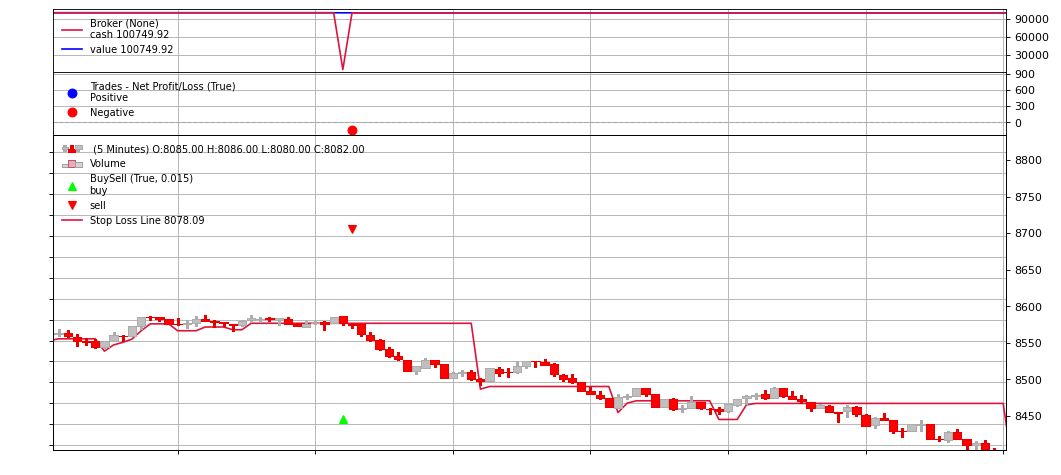

In [135]:
run_backtest(df=base, initial_cash=100000, commission=0.00013,include_short=False)

开始回测
初始资金: 100,000.00
策略模式: 仅多头策略
2026-07-02 10:18, 做空信号触发, 价格: 8608.20
2026-07-02 10:19, 卖出开仓执行, 价格: 8608.20, 成本: -94690.20, 佣金: 14.20
2026-07-02 10:20, 平仓条件触发: 止损, 当前价: 8618.60, 止损价: 8616.70
2026-07-02 10:21, 买入平仓执行, 价格: 8618.80, 成本: -94690.20, 佣金: 14.22
2026-07-02 10:21, 交易利润, 毛利润: -116.60, 净利润: -145.02
2026-07-06 13:09, 做空信号触发, 价格: 8488.40
2026-07-06 13:10, 卖出开仓执行, 价格: 8488.40, 成本: -93372.40, 佣金: 14.01
2026-07-06 13:26, 平仓条件触发: 止损, 当前价: 8471.80, 止损价: 8465.77
2026-07-06 13:27, 买入平仓执行, 价格: 8472.20, 成本: -93372.40, 佣金: 13.98
2026-07-06 13:27, 交易利润, 毛利润: 178.20, 净利润: 150.22
2026-07-10 13:33, 做空信号触发, 价格: 8576.60
2026-07-10 13:34, 卖出开仓执行, 价格: 8576.00, 成本: -94336.00, 佣金: 14.15
2026-07-10 13:42, 平仓条件触发: 止损, 当前价: 8527.00, 止损价: 8526.52
2026-07-10 13:43, 买入平仓执行, 价格: 8527.00, 成本: -94336.00, 佣金: 14.07
2026-07-10 13:43, 交易利润, 毛利润: 539.00, 净利润: 510.78
2026-07-14 14:58, 做空信号触发, 价格: 8120.40
2026-07-14 14:59, 卖出开仓执行, 价格: 8121.20, 成本: -89333.20, 佣金: 13.40
2026-07-15 09:45, 平仓条件触发: 止损, 当前价: 8110.00, 止损

<IPython.core.display.Javascript object>


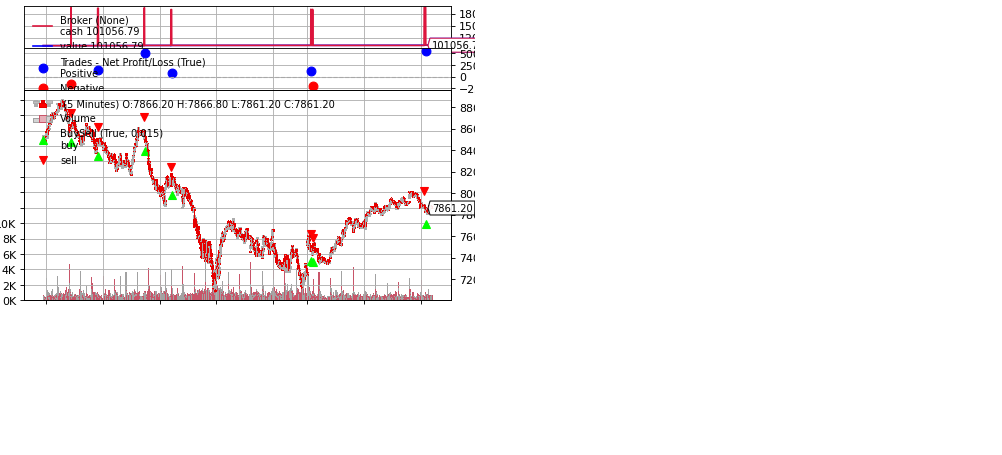

In [87]:
run_backtest(df=base, initial_cash=100000, commission=0.00013,include_short=False)

开始回测
初始资金: 100,000.00
2025-08-11, 买入信号触发, 价格: 6089.60
2025-08-11, 买入执行, 价格: 6089.60, 成本: 91344.00, 佣金: 91.34
2025-08-11, 卖出条件触发: 止损, 当前价: 6123.60, 止损价: 6131.34
2025-08-11, 卖出执行, 价格: 6123.60, 成本: 91344.00, 佣金: 91.85
2025-08-11, 交易利润, 毛利润: 510.00, 净利润: 326.80
2025-08-15, 买入信号触发, 价格: 6270.40
2025-08-15, 买入执行, 价格: 6272.40, 成本: 94086.00, 佣金: 94.09
2025-08-18, 卖出条件触发: 止损, 当前价: 6407.80, 止损价: 6427.85
2025-08-18, 卖出执行, 价格: 6407.80, 成本: 94086.00, 佣金: 96.12
2025-08-18, 交易利润, 毛利润: 2031.00, 净利润: 1840.80
2025-09-11, 买入信号触发, 价格: 6702.00
2025-09-11, 买入执行, 价格: 6701.80, 成本: 93825.20, 佣金: 93.83
2025-09-12, 卖出条件触发: 止损, 当前价: 6992.80, 止损价: 7000.11
2025-09-12, 卖出执行, 价格: 6992.40, 成本: 93825.20, 佣金: 97.89
2025-09-12, 交易利润, 毛利润: 4068.40, 净利润: 3876.68
2025-09-30, 期末资金: 106044.28
回测结果
最终资金: 106,044.28
总收益率: 6.04%
夏普比率: 0.000
最大回撤: 0.82%
年化收益率: 0.00%
总交易次数: 3
盈利交易比例: 66.7%
平均每笔利润: 126.25

正在生成图表...


<IPython.core.display.Javascript object>


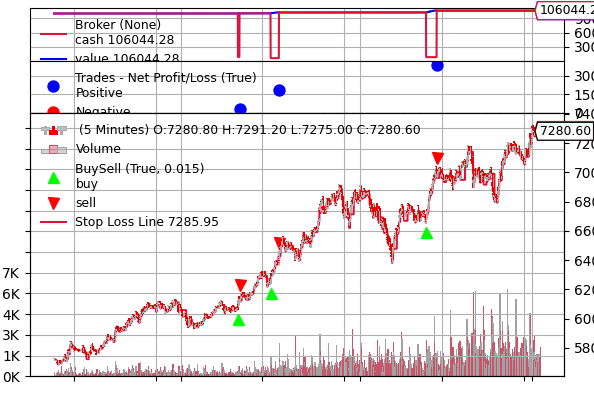

In [383]:
run_backtest(df=data, initial_cash=100000, commission=0.001)

In [254]:
    base = data.copy()
    大阳 = base.zd_strength >= para['K线']['大阴']
    temp = 大阳*base.close - base.ma_body * 大阳 * para['stop_loss']['long']['buffer_ratio']   
    test = temp.replace(0, np.nan).ffill()

In [358]:
base = data.copy()
#     找到大于2倍ma_boday 的大阳 做标准化
大阳 = base.zd_strength >= para['K线']['大阳']
中阳 = (base.zd_strength >= para['K线']['中阳']) & (大阳==False)
temp = (大阳*base.close - base.ma_body * 大阳 * 3 ) + (中阳*base.open - 中阳*base.ma_body)

In [528]:
# test1.loc['2025-07-09 14:50:00':]

In [529]:
    cerebro = bt.Cerebro()
    
    # 检查数据格式
#     print("数据前5行:")
#     print(df.head())
#     print("\n数据信息:")
#     print(df.info())
    
    # 确保索引是datetime类型
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
    
    # 创建数据feed
    data = CustomData(
        dataname=df,
        open='open',
        high='high',
        low='low',
        close='close',
        volume='volume',
        long='long',
        stop_loss_long='stop_loss_long',
        sell='sell',
        timeframe=bt.TimeFrame.Minutes,  # 设置为分钟线
        compression=5,  # 周期为5分钟
        openinterest=None
    )
    
    cerebro.adddata(data)
  
    # 添加策略
    cerebro.addstrategy(SignalStrategy)
    
    # 设置初始资金
    cerebro.broker.setcash(initial_cash)
    
    # 设置佣金
    cerebro.broker.setcommission(commission=commission)
    
    # 添加分析器
    cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='sharpe', riskfreerate=0.0)
    cerebro.addanalyzer(bt.analyzers.DrawDown, _name='drawdown')
    cerebro.addanalyzer(bt.analyzers.Returns, _name='returns')
    cerebro.addanalyzer(bt.analyzers.TradeAnalyzer, _name='trades')
#     cerebro.addanalyzer(bt.analyzers.AnnualReturn, _name='annualreturn')
    cerebro.addanalyzer(AnnualReturnAnalyzer, _name='_AnnualReturn')

    print('=' * 50)
    print('开始回测')
    print('=' * 50)
    print(f'初始资金: {initial_cash:,.2f}')
    
    # 运行回测
    results = cerebro.run()
    strat = results[0]
    
    # 打印最终结果
    print('=' * 50)
    print('回测结果')
    print('=' * 50)
    print(f'最终资金: {cerebro.broker.getvalue():,.2f}')
    print(f'总收益率: {(cerebro.broker.getvalue()/initial_cash-1)*100:.2f}%')
    
    # 分析结果
#     sharpe = strat.analyzers.sharpe.get_analysis()
#     drawdown = strat.analyzers.drawdown.get_analysis()
#     returns = strat.analyzers.returns.get_analysis()
#     trades = strat.analyzers.trades.get_analysis()

#     print(f"夏普比率: {sharpe.get('sharperatio', 0):.3f}")
#     print(f"最大回撤: {drawdown['max']['drawdown']:.2f}%")
#     print(f"年化收益率: {returns.get('rnorm100', 0):.2f}%")

    # 安全获取分析结果
    sharpe_analysis = safe_get_analysis(strat.analyzers.sharpe)
    drawdown_analysis = safe_get_analysis(strat.analyzers.drawdown)
    trades_analysis = safe_get_analysis(strat.analyzers.trades)
    returns_analysis = safe_get_analysis(strat.analyzers.returns)
#     returns_analysis = safe_get_analysis(strat.analyzers.annualreturn)
    returns_analysis = strat.analyzers._AnnualReturn.get_analysis()

    trades = strat.analyzers.trades.get_analysis()


#     # 安全打印夏普比率
#     sharpe_ratio = sharpe_analysis.get('sharperatio', 0)
#     print(f"夏普比率: {format_value(sharpe_ratio, '.3f')}")    
#     # 安全打印最大回撤
#     max_drawdown = drawdown_analysis.get('max', {}).get('drawdown', 0)
#     print(f"最大回撤: {format_value(max_drawdown, '.2f')}%")  
#     # 安全打印年化收益率
#     annual_return = returns_analysis.get('rnorm100', 0)
#     print(f"年化收益率: {format_value(annual_return, '.2f')}%")
    
#     # 交易统计
#     if 'total' in trades:
#         print(f"总交易次数: {trades['total']['total']}")
#         if trades['total']['total'] > 0:
#             print(f"盈利交易比例: {trades['won']['total']/trades['total']['total']*100:.1f}%")
#             print(f"平均每笔利润: {trades['pnl']['net']['average']:.2f}")
    
#     # 启用交互模式
#     plt.ion()
#     # 绘制图表
#     print('\n正在生成图表...')
#     cerebro.plot(style='candlestick', volume=True)

开始回测
初始资金: 100,000.00
2025-08-11 09:35, 买入信号触发, 价格: 6089.60
2025-08-11 09:40, 买入执行, 价格: 6089.60, 成本: 91344.00, 佣金: 91.34
2025-09-11 09:55, 卖出条件触发: 止损, 当前价: 6694.80, 止损价: 6700.59
2025-09-11 10:00, 卖出执行, 价格: 6696.60, 成本: 91344.00, 佣金: 100.45
2025-09-11 10:00, 交易利润, 毛利润: 9105.00, 净利润: 8913.21
2025-09-30 15:00, 期末资金: 108913.21
回测结果
最终资金: 108,913.21
总收益率: 8.91%


In [535]:
# returns_analysis.get('start_date', 0)
# returns_analysis.get('end_date', 0)
# returns_analysis.get('total_days', 0)
returns_analysis.get('annual_return', 0)

0.4560515168431256

开始回测
初始资金: 100,000.00
2025-08-11, 买入信号触发, 价格: 6089.60
2025-08-11, 买入执行, 价格: 6089.60, 成本: 91344.00, 佣金: 91.34
2025-08-11, 卖出条件触发: 止损, 当前价: 6133.00, 止损价: 6137.56
2025-08-11, 卖出执行, 价格: 6132.20, 成本: 91344.00, 佣金: 91.98
2025-08-11, 交易利润, 毛利润: 639.00, 净利润: 455.67
2025-08-15, 买入信号触发, 价格: 6270.40
2025-08-15, 买入执行, 价格: 6272.40, 成本: 94086.00, 佣金: 94.09
2025-08-15, 卖出条件触发: 止损, 当前价: 6297.60, 止损价: 6299.42
2025-08-15, 卖出执行, 价格: 6297.20, 成本: 94086.00, 佣金: 94.46
2025-08-15, 交易利润, 毛利润: 372.00, 净利润: 183.46
2025-09-11, 买入信号触发, 价格: 6702.00
2025-09-11, 买入执行, 价格: 6701.80, 成本: 93825.20, 佣金: 93.83
2025-09-11, 卖出条件触发: 止损, 当前价: 6694.80, 止损价: 6694.92
2025-09-11, 卖出执行, 价格: 6696.60, 成本: 93825.20, 佣金: 93.75
2025-09-11, 交易利润, 毛利润: -72.80, 净利润: -260.38
2025-09-30, 期末资金: 100378.75
回测结果
最终资金: 100,378.75
总收益率: 0.38%
夏普比率: 0.000
最大回撤: 0.60%
年化收益率: 1.60%
总交易次数: 3
盈利交易比例: 66.7%
平均每笔利润: 126.25

正在生成图表...


<IPython.core.display.Javascript object>


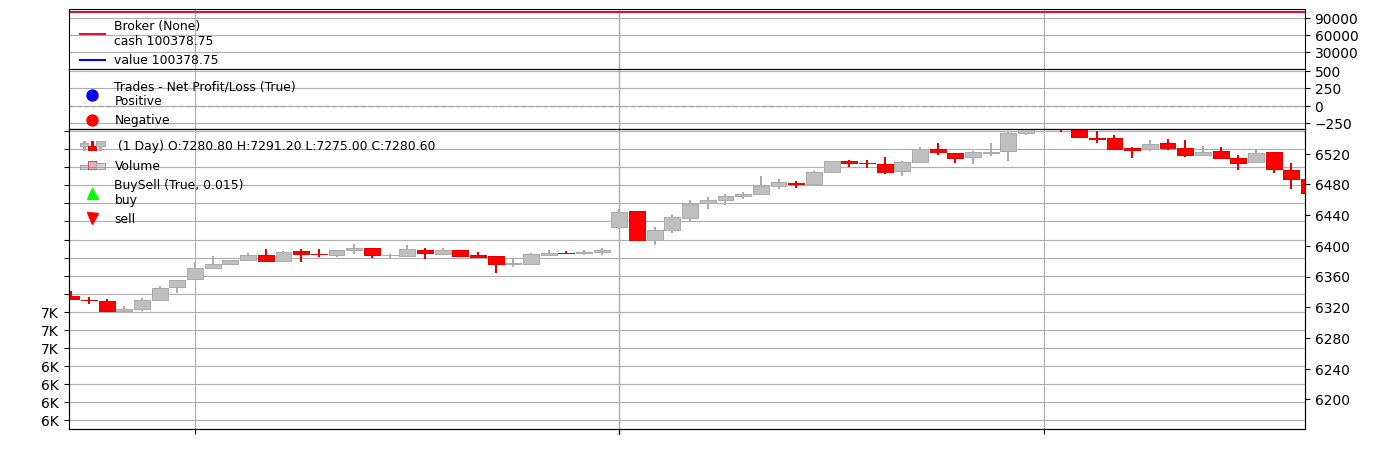

[[<Figure size 432x288 with 4 Axes>]]

In [97]:
    df =base
    initial_cash=100000
    commission=0.001
    # 创建Cerebro引擎
    cerebro = bt.Cerebro()
    
    # 添加策略
    cerebro.addstrategy(SignalStrategy)
    
    # 检查数据格式
#     print("数据前5行:")
#     print(df.head())
#     print("\n数据信息:")
#     print(df.info())
    
    # 确保索引是datetime类型
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
    
    # 创建数据feed
    data = CustomData(
        dataname=df,
        open='open',
        high='high',
        low='low',
        close='close',
        volume='volume',
        long='long',
        stop_loss_long='stop_loss_long',
        sell='sell',
        openinterest=None
    )
    
    cerebro.adddata(data)
    
    # 设置初始资金
    cerebro.broker.setcash(initial_cash)
    
    # 设置佣金
    cerebro.broker.setcommission(commission=commission)
    
    # 添加分析器
    cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='sharpe', riskfreerate=0.0)
    cerebro.addanalyzer(bt.analyzers.DrawDown, _name='drawdown')
    cerebro.addanalyzer(bt.analyzers.Returns, _name='returns')
    cerebro.addanalyzer(bt.analyzers.TradeAnalyzer, _name='trades')
    cerebro.addanalyzer(bt.analyzers.AnnualReturn, _name='annualreturn')
    
    print('=' * 50)
    print('开始回测')
    print('=' * 50)
    print(f'初始资金: {initial_cash:,.2f}')
    
    # 运行回测
    results = cerebro.run()
    strat = results[0]
    
    # 打印最终结果
    print('=' * 50)
    print('回测结果')
    print('=' * 50)
    print(f'最终资金: {cerebro.broker.getvalue():,.2f}')
    print(f'总收益率: {(cerebro.broker.getvalue()/initial_cash-1)*100:.2f}%')
    
    # 分析结果
#     sharpe = strat.analyzers.sharpe.get_analysis()
#     drawdown = strat.analyzers.drawdown.get_analysis()
#     returns = strat.analyzers.returns.get_analysis()
#     trades = strat.analyzers.trades.get_analysis()

#     print(f"夏普比率: {sharpe.get('sharperatio', 0):.3f}")
#     print(f"最大回撤: {drawdown['max']['drawdown']:.2f}%")
#     print(f"年化收益率: {returns.get('rnorm100', 0):.2f}%")

    # 安全获取分析结果
    sharpe_analysis = safe_get_analysis(strat.analyzers.sharpe)
    drawdown_analysis = safe_get_analysis(strat.analyzers.drawdown)
    returns_analysis = safe_get_analysis(strat.analyzers.returns)
    trades_analysis = safe_get_analysis(strat.analyzers.trades)

    # 安全打印夏普比率
    sharpe_ratio = sharpe_analysis.get('sharperatio', 0)
    print(f"夏普比率: {format_value(sharpe_ratio, '.3f')}")    
    # 安全打印最大回撤
    max_drawdown = drawdown_analysis.get('max', {}).get('drawdown', 0)
    print(f"最大回撤: {format_value(max_drawdown, '.2f')}%")  
    # 安全打印年化收益率
    annual_return = returns_analysis.get('rnorm100', 0)
    print(f"年化收益率: {format_value(annual_return, '.2f')}%")
    
    # 交易统计
    if 'total' in trades:
        print(f"总交易次数: {trades['total']['total']}")
        if trades['total']['total'] > 0:
            print(f"盈利交易比例: {trades['won']['total']/trades['total']['total']*100:.1f}%")
            print(f"平均每笔利润: {trades['pnl']['net']['average']:.2f}")
    
    # 启用交互模式
    plt.ion()
    # 绘制图表
    print('\n正在生成图表...')
    cerebro.plot(style='candlestick', volume=True)

In [149]:
    df =data
    initial_cash=100000
    commission=0.001
    # 创建Cerebro引擎
    cerebro = bt.Cerebro()
    
    # 添加策略
    cerebro.addstrategy(SignalStrategy)
    
    # 检查数据格式
#     print("数据前5行:")
#     print(df.head())
#     print("\n数据信息:")
#     print(df.info())
    
    # 确保索引是datetime类型
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
    
    # 创建数据feed
    data = CustomData(
        dataname=df,
        open='open',
        high='high',
        low='low',
        close='close',
        volume='volume',
        long='long',
        stop_loss_long='stop_loss_long',
        sell='sell',
        openinterest=None
    )
    
    cerebro.adddata(data)
    
    # 设置初始资金
    cerebro.broker.setcash(initial_cash)
    
    # 设置佣金
    cerebro.broker.setcommission(commission=commission)
    
    # 添加分析器
    cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='sharpe', riskfreerate=0.0)
    cerebro.addanalyzer(bt.analyzers.DrawDown, _name='drawdown')
    cerebro.addanalyzer(bt.analyzers.Returns, _name='returns')
    cerebro.addanalyzer(bt.analyzers.TradeAnalyzer, _name='trades')
    cerebro.addanalyzer(bt.analyzers.AnnualReturn, _name='annualreturn')
    
    print('=' * 50)
    print('开始回测')
    print('=' * 50)
    print(f'初始资金: {initial_cash:,.2f}')
    
    # 运行回测
    results = cerebro.run()
    strat = results[0]
    
    # 打印最终结果
    print('=' * 50)
    print('回测结果')
    print('=' * 50)
    print(f'最终资金: {cerebro.broker.getvalue():,.2f}')
    print(f'总收益率: {(cerebro.broker.getvalue()/initial_cash-1)*100:.2f}%')
    
    # 分析结果
#     sharpe = strat.analyzers.sharpe.get_analysis()
#     drawdown = strat.analyzers.drawdown.get_analysis()
#     returns = strat.analyzers.returns.get_analysis()
#     trades = strat.analyzers.trades.get_analysis()

#     print(f"夏普比率: {sharpe.get('sharperatio', 0):.3f}")
#     print(f"最大回撤: {drawdown['max']['drawdown']:.2f}%")
#     print(f"年化收益率: {returns.get('rnorm100', 0):.2f}%")

    # 安全获取分析结果
    sharpe_analysis = safe_get_analysis(strat.analyzers.sharpe)
    drawdown_analysis = safe_get_analysis(strat.analyzers.drawdown)
    returns_analysis = safe_get_analysis(strat.analyzers.returns)
    trades_analysis = safe_get_analysis(strat.analyzers.trades)

    # 安全打印夏普比率
    sharpe_ratio = sharpe_analysis.get('sharperatio', 0)
    print(f"夏普比率: {format_value(sharpe_ratio, '.3f')}")    
    # 安全打印最大回撤
    max_drawdown = drawdown_analysis.get('max', {}).get('drawdown', 0)
    print(f"最大回撤: {format_value(max_drawdown, '.2f')}%")  
    # 安全打印年化收益率
    annual_return = returns_analysis.get('rnorm100', 0)
    print(f"年化收益率: {format_value(annual_return, '.2f')}%")
    
    # 交易统计
    if 'total' in trades:
        print(f"总交易次数: {trades['total']['total']}")
        if trades['total']['total'] > 0:
            print(f"盈利交易比例: {trades['won']['total']/trades['total']['total']*100:.1f}%")
            print(f"平均每笔利润: {trades['pnl']['net']['average']:.2f}")
    
    # 启用交互模式
    plt.ion()
    # 绘制图表
    print('\n正在生成图表...')
    cerebro.plot(style='candlestick', volume=True)

开始回测
初始资金: 100,000.00
2025-08-11, 买入信号触发, 价格: 6089.60
2025-08-11, 买入执行, 价格: 6089.60, 成本: 91344.00, 佣金: 91.34
2025-09-11, 卖出条件触发: 止损, 当前价: 6694.80, 止损价: 6700.59
2025-09-11, 卖出执行, 价格: 6696.60, 成本: 91344.00, 佣金: 100.45
2025-09-11, 交易利润, 毛利润: 9105.00, 净利润: 8913.21
2025-09-30, 期末资金: 108913.21
回测结果
最终资金: 108,913.21
总收益率: 8.91%
夏普比率: 0.000
最大回撤: 6.94%
年化收益率: 43.13%
总交易次数: 3
盈利交易比例: 66.7%
平均每笔利润: 126.25

正在生成图表...


[[<Figure size 1211.38x409.75 with 4 Axes>]]

In [593]:
get_peak_vally_stats(base[['close']],conf['zig']['zig1'])

,close,peak,valley,p_v_value,p_v_value_bw,p_pos,v_pos,z_pos,dw_pct_last,up_pct_last,...,z_pct_prev_avg_k,z_pct_avg_k,p_prev1_,v_prev1_,up_cnt_,up_pct_,up_pct_avg_,dw_cnt_,dw_pct_,dw_pct_avg_
time,,,,,,,,,,,,,,,,,,,,,
2025-07-09 13:05:00,5725.4,NaN,5725.4,5725.4,5725.4,NaN,NaN,NaN,NaN,0.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-09 13:10:00,5724.6,NaN,5725.4,5725.4,5728.0,NaN,NaN,NaN,NaN,0.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-09 13:15:00,5728.0,5728.0,5725.4,5728.0,5728.0,NaN,NaN,NaN,0.0000,0.4541,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-09 13:20:00,5727.0,5728.0,5725.4,5728.0,5696.8,NaN,NaN,NaN,0.0000,0.4541,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-09 13:25:00,5728.0,5728.0,5725.4,5728.0,5696.8,NaN,NaN,NaN,0.0000,0.4541,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-09 13:30:00,5721.6,5728.0,5725.4,5728.0,5696.8,NaN,NaN,NaN,0.0000,0.4541,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-09 13:35:00,5720.2,5728.0,5725.4,5728.0,5696.8,NaN,NaN,NaN,0.0000,0.4541,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-09 13:40:00,5718.2,5728.0,5725.4,5728.0,5696.8,NaN,NaN,NaN,0.0000,0.4541,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-09 13:45:00,5720.6,5728.0,5725.4,5728.0,5696.8,NaN,NaN,NaN,0.0000,0.4541,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [599]:
base[['z_pct_curr1','v_pct_curr1']]

KeyError: "['v_pct_curr1'] not in index"

In [581]:
conf['zig']['zig1']

0.002